In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


In [4]:
df = pd.read_excel(
    "final project overbooking data.xlsx",
    header=1,                 # use row 2 as the header
    usecols="A:C,E:F,H"       # skip the blank columns
)

df.columns = df.columns.str.strip()
df

,flight,Booked,No shows,bumped,total compensation,compensation per bumped passenger
0,1,255,12,0,0,0.000000
1,2,255,17,0,0,0.000000
2,3,255,12,0,0,0.000000
3,4,255,17,0,0,0.000000
4,5,255,17,0,0,0.000000
...,...,...,...,...,...,...
495,496,295,15,30,22427,747.566667
496,497,295,18,27,18344,679.407407
497,498,295,14,31,23805,767.903226
498,499,295,10,35,30008,857.371429


In [5]:
print(df.columns)

Index(['flight', 'Booked', 'No shows', 'bumped', 'total compensation',
       'compensation per bumped passenger'],
      dtype='object')


In [6]:
#Compute show_ups, boarded, and profit

SEATS = 250
FIXED_COST = 70000
TICKET_REVENUE = 600

df["show_ups"] = df["Booked"] - df["No shows"]
df["boarded"] = np.minimum(df["show_ups"], SEATS)
df["profit"] = TICKET_REVENUE * df["boarded"] - FIXED_COST - df["total compensation"]

df.head()

,flight,Booked,No shows,bumped,total compensation,compensation per bumped passenger,show_ups,boarded,profit
0,1,255,12,0,0,0.0,243,243,75800
1,2,255,17,0,0,0.0,238,238,72800
2,3,255,12,0,0,0.0,243,243,75800
3,4,255,17,0,0,0.0,238,238,72800
4,5,255,17,0,0,0.0,238,238,72800


In [12]:
#Group by booking level and get average profit

summary = (
    df.groupby("Booked", as_index=False)
      .agg(
          avg_profit=("profit", "mean"),
          avg_no_shows=("No shows", "mean"),
          avg_bumped=("bumped", "mean"),
          avg_show_ups=("show_ups", "mean")
      )
      .sort_values("avg_profit", ascending=False)
)

summary

,Booked,avg_profit,avg_no_shows,avg_bumped,avg_show_ups
1,265,78945.56,13.67,2.30,251.33
2,275,76270.14,14.19,10.81,260.81
0,255,75168.84,13.04,0.01,241.96
3,285,68274.45,14.09,20.91,270.91
4,295,57924.74,15.45,29.55,279.55


In [13]:
#Pick the booking level with the highest average profit
summary.iloc[0]

Booked            265.00
avg_profit      78945.56
avg_no_shows       13.67
avg_bumped          2.30
avg_show_ups      251.33
Name: 1, dtype: float64

In [11]:
df[["Booked", "No shows", "show_ups", "bumped", "boarded", "total compensation", "profit"]].head(15)

,Booked,No shows,show_ups,bumped,boarded,total compensation,profit
0,255,12,243,0,243,0,75800
1,255,17,238,0,238,0,72800
2,255,12,243,0,243,0,75800
3,255,17,238,0,238,0,72800
4,255,17,238,0,238,0,72800
5,255,7,248,0,248,0,78800
6,255,12,243,0,243,0,75800
7,255,8,247,0,247,0,78200
8,255,16,239,0,239,0,73400
9,255,15,240,0,240,0,74000


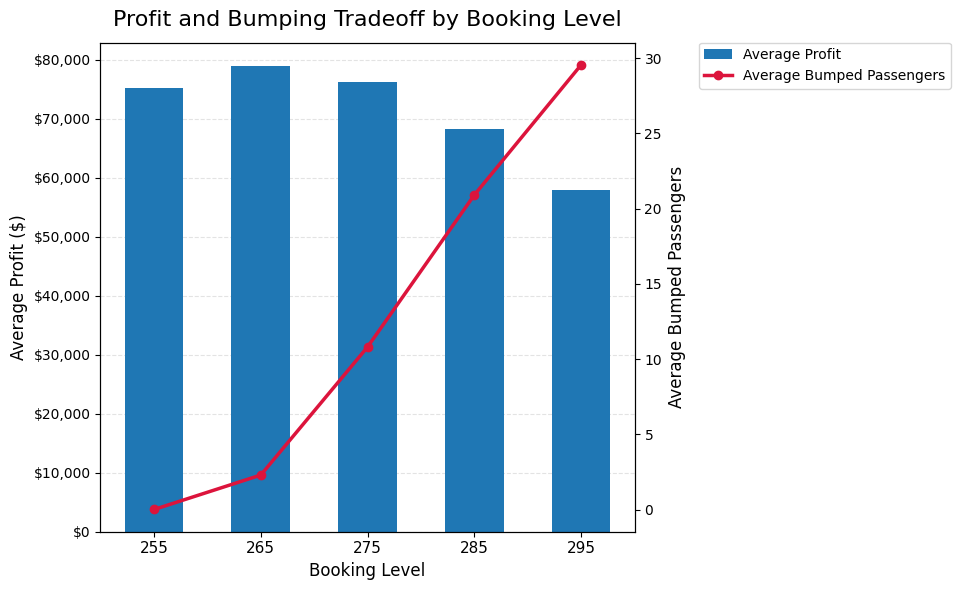

In [23]:
tradeoff = (
    df.groupby("Booked", as_index=False)
      .agg(
          avg_profit=("profit", "mean"),
          avg_bumped=("bumped", "mean")
      )
      .sort_values("Booked")
)

x = np.arange(len(tradeoff))
labels = tradeoff["Booked"].astype(str)

fig, ax1 = plt.subplots(figsize=(10, 6))

bars = ax1.bar(
    x,
    tradeoff["avg_profit"],
    width=0.55,
    label="Average Profit"
)

ax1.set_xlabel("Booking Level", fontsize=12)
ax1.set_ylabel("Average Profit ($)", fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=11)
ax1.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"${y:,.0f}"))
ax1.grid(axis="y", linestyle="--", alpha=0.35)
ax1.set_axisbelow(True)

ax2 = ax1.twinx()
ax2.plot(
    x,
    tradeoff["avg_bumped"],
    marker="o",
    linewidth=2.5,
    color="crimson",
    label="Average Bumped Passengers"
)
ax2.set_ylabel("Average Bumped Passengers", fontsize=12)

plt.title("Profit and Bumping Tradeoff by Booking Level", fontsize=16, pad=12)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper left",
    bbox_to_anchor=(1.12, 1),
    borderaxespad=0,
    frameon=True
)

plt.tight_layout()
plt.show()

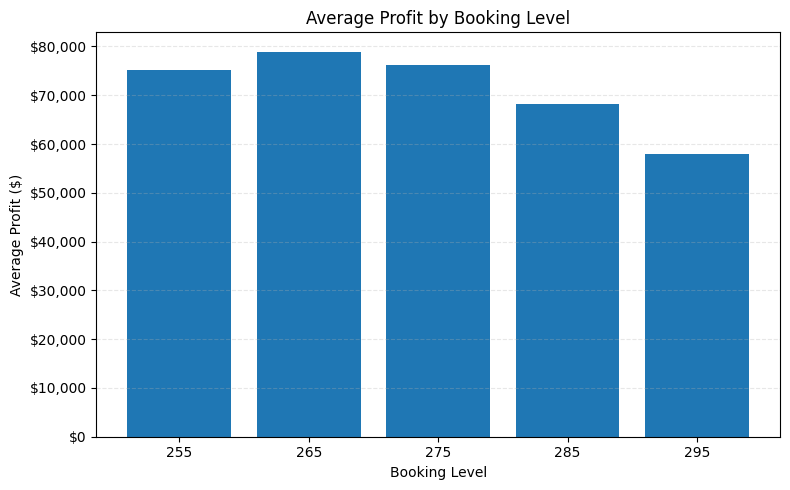

In [24]:

profit_summary = (
    df.groupby("Booked", as_index=False)["profit"]
      .mean()
      .sort_values("Booked")
      .rename(columns={"profit": "avg_profit"})
)

plt.figure(figsize=(8,5))
plt.bar(profit_summary["Booked"].astype(str), profit_summary["avg_profit"])
plt.xlabel("Booking Level")
plt.ylabel("Average Profit ($)")
plt.title("Average Profit by Booking Level")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"${y:,.0f}"))
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()